Introduction:
The dataset shows us the GDP Growth of the US in various quarters of the year ranging from 2010 to 2023, which includes the GDP growth spikes in 2020 due to COVID. This data is from the U.S. Bureau of Economic Analysis (BEA). The three methods I am using to analyze the data will be Cubic Spline Interpolation, a degree 4 polynomial using least squares method, and a least squares linear model.

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# DATASET
y = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3
])

n = len(y)
x = np.arange(1, n + 1)

# PART A: NATURAL CUBIC SPLINE
#_____________________________
def nat_cubic_spline(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros((n-2, n-2))
    rhs = np.zeros(n-2)
    
#Loop to define cubic spline

    for i in range(n-2):
        if i > 0:
            A[i, i-1] = h[i]
        A[i, i] = 2 * (h[i] + h[i+1])
        if i < n-3:
            A[i, i+1] = h[i+1]

        rhs[i] = 6 * ((y[i+2] - y[i+1]) / h[i+1] - (y[i+1] - y[i]) / h[i])

    M = np.zeros(n)
    M[1:-1] = np.linalg.solve(A, rhs) 

    return M

def eval_spline(x, y, M, xq):
    n = len(x)
    yq = np.zeros_like(xq)

    for j, val in enumerate(xq):
        i = np.searchsorted(x, val) - 1
        if i == n - 1:
            i -= 1
        if i < 0:
            i = 0

        h = x[i+1] - x[i]

        term1 = M[i] * (x[i+1] - val)**3 / (6*h)
        term2 = M[i+1] * (val - x[i])**3 / (6*h)
        term3 = (y[i] - M[i]*h*h/6) * (x[i+1] - val) / h
        term4 = (y[i+1] - M[i+1]*h*h/6) * (val - x[i]) / h

        yq[j] = term1 + term2 + term3 + term4

    return yq

M = nat_cubic_spline(x, y)
x_dense = np.linspace(1, n, 500)
y_spline = eval_spline(x, y, M, x_dense)


Part A Report:
To determine the number of unknown coefficients, we have to know that the cubic spline will go through 20 data points, as counted in the data set. Therefore we know that it will also contain 19 segments. Each segment will contain 4 unknown coefficients (a, b, c, d). We multiply 19 segments by 4 unknown coefficients and we get a total of 76 unknown coefficients. At each interior knot, the most basic continuity condition is that the graph has to be connected. Basically saying that there should be no gaps between each data point on the graph. Another continuity condition is that the slopes have to be the same on both sides of the data point. This makes the graph smooth and wil have no sudden slope changes that will form a sharp corner. Therefore, the last continuity condition is that the rate of change of the slope also has to be the same at each interior knot. 
Looking at the graph of the cubic spline, the interpolant mostly follows the data smoothly. The only time it doesn't is when the graph spikes during data points of 2020 Q2-Q3. The extremely high values of these two points cause the graph to have unnatural spikes and changes in this region. 
The large swing due to the data values of 2020 Q2 and Q3 makes the spline adjust heavily to these points, causing very steep slopes, which can effect adjacent segments in the graph by heavily increasing the slope of the graph in those points too. This can be described as the Runge Phenomenon. Even though the Runge Phenomenon is usually about high-degree global polynomials, the reason why it can be applied to our graph is due to the huge outliers in oue data, causing the intense oscillation in the cubic spline graph, which is supposed to prevent this. Weighted least squares method would be the most preferred to solve this problem because it will assign lower weights to the outlier data points, which will reduce their effect on the graph. This will be better than smoothing the spline as smoothing the spline will make the data less accurate than using the weighted least squares method. 

In [33]:

# PART B1: DEGREE-4 POLYNOMIAL FITTING
#_____________________________
def poly_fit(x, y, degree):
    A = np.vander(x, degree + 1, increasing=True)
    ATA = A.T @ A
    ATy = A.T @ y
    coeffs = np.linalg.solve(ATA, ATy)
    return coeffs

def eval_poly(coeffs, x):
    return sum(c * x**i for i, c in enumerate(coeffs))

degree = 4
coeffs = poly_fit(x, y, degree)
y_poly = eval_poly(coeffs, x_dense)

# PART B2: LINEAR MODEL (WITH COVID)
#___________________________________
A_full = np.vstack([x, np.ones(len(x))]).T
ATA_full = A_full.T @ A_full
ATy_full = A_full.T @ y

slope_full, intercept_full = np.linalg.solve(ATA_full, ATy_full)
y_lin_full = slope_full * x_dense + intercept_full

# PART B2: LINEAR MODEL (WITHOUT COVID)
#______________________________________
mask = np.ones(n, dtype=bool)
mask[13:17] = False  # removes 2020 Q1–2021 Q1

x_lin = x[mask]
y_lin = y[mask]

A_lin = np.vstack([x_lin, np.ones(len(x_lin))]).T
ATA_lin = A_lin.T @ A_lin
ATy_lin = A_lin.T @ y_lin

slope_ex, intercept_ex = np.linalg.solve(ATA_lin, ATy_lin)
y_lin_excluded = slope_ex * x_dense + intercept_ex

print("Slope (with COVID):", slope_full)
print("Slope (without COVID):", slope_ex)

# RMSE
# _____
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

y_poly_points = eval_poly(coeffs, x)
y_spline_points = eval_spline(x, y, M, x)

print("RMSE (Polynomial):", rmse(y, y_poly_points))
print("RMSE (Spline):", rmse(y, y_spline_points))

Slope (with COVID): 0.04571428571428575
Slope (without COVID): -0.017336448598130803
RMSE (Polynomial): 9.965326786519533
RMSE (Spline): 0.47010637094172614


Part B:
The degree 4 polynomial graph fits the data more than the cubic spline graph as the outlier data points do not effect the overall shape of the graph. The trend for the degree 4 polynomial graph is kept relatively the same thorughout the graph, while the cubic spline spikes massively once it encounters the 2020 Q2 and Q3 data points. However, the cubic spline reproduces every data point exactly, while the degree 4 polynomial does not because it does not capture the spike of magnitude of the 2020 Q2 and Q3 data points. This allows us to evaluate the trade-off between approximation and interpolation. In the case of the cubic spline, the data points are represented exactly as how the data shows, but this comes at the cost of the interpolation being massively spiked, causing a huge change in the slope of the graph. On the other hand, the least squares method's interpolation is much more accurate, and does not experience the massive spike in slope like the cubic spline does. This of course comes with the trade off of approximating data, making it so that the degree 4 polynomial graph does not accurately represent the data points for the 2020 Q2 and Q3 sections. 
When we graph the least squares linear fit with the COVID data points excluded, we can see that the slope of the linear graph is effectively 0. Even though the linear model is straightforward. it does not make the best economic sense for this data because it lies on many assumptions. Some of these assumptons include that the GDP growth changes at a constant rate over time and that the error terms are independent.

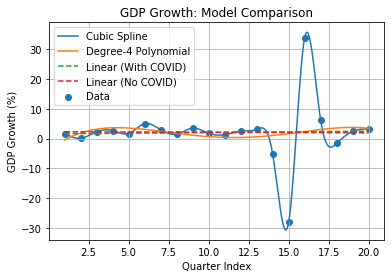

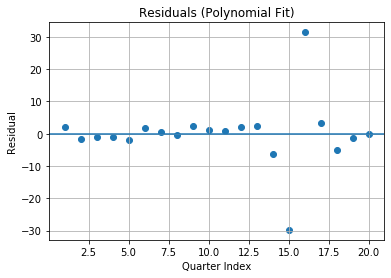

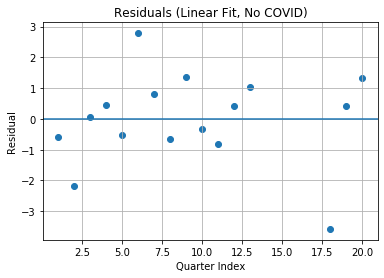

In [34]:

# MAIN PLOT (Plots all graph lines on one plot to compare)
#__________________________________________________________
plt.figure()

plt.scatter(x, y, label="Data")

plt.plot(x_dense, y_spline, label="Cubic Spline")
plt.plot(x_dense, y_poly, label="Degree-4 Polynomial")

plt.plot(x_dense, y_lin_full, linestyle='--', label="Linear (With COVID)")
plt.plot(x_dense, y_lin_excluded, linestyle='--', label="Linear (No COVID)")

plt.title("GDP Growth: Model Comparison")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid()

plt.show()

# RESIDUALS (Polynomial Fitting Including COVID)
#_______________________
r_poly = y - y_poly_points

plt.figure()
plt.scatter(x, r_poly)
plt.axhline(0)
plt.title("Residuals (Polynomial Fit)")
plt.xlabel("Quarter Index")
plt.ylabel("Residual")
plt.grid()
plt.show()

# RESIDUALS (Linear Excluding COVID)
#_____________________________
y_lin_pred = slope_ex * x_lin + intercept_ex
r_lin = y_lin - y_lin_pred

plt.figure()
plt.scatter(x_lin, r_lin)
plt.axhline(0)
plt.title("Residuals (Linear Fit, No COVID)")
plt.xlabel("Quarter Index")
plt.ylabel("Residual")
plt.grid()
plt.show()

Part C Report:
I would recommend the cubic spline method to policymakers. This is because while the interpolation of the cubic spline can be affected by outliers, outliers to data rarely happen and can sometimes be removed from data to make accurate data. Cubic spline is good because the data points of cubic spline are represented exactly as the data points are shown, which are good for providing policymakers with accurate data as it goes throught each data point. The cubic spline method is relatively smooth too, as long as no outliers are present in the data. With no outliers, the cubic spline is the preferred method as it provides smooth and accurate data. The only problem with it, as mentioned earlier, is that if outliers are introduced in the data, the interpolation of the cubic spline graph can be effected and can provide inaccurate data because of the outlier. 
Big O Report:
The Big O is a mathematical tool that describes the upper bound of a program's time complexity. It shows how runtime increases as the input size increases, showing a proportional relationship between runtime and input size. The Big O does not change my recommendation because algorithms that contain data points wouldn't really take more than a few milliseconds to run. The runtime of a program will only be relatively long when there are thousands of inputs, and even so, it would be a few seconds. Therefore I do not think the Big O notation will have any effect on how the data will be portrayed, so it does not change my recommendation.



Conclusion:
In conclusion, this project used the cubic spline method and the polynomial method to analyze and graph a dataset and I determined what each method was best at and what it was lacking in. 
The cubic spline method is best used for interpolation because it represents each data point exactly. This makes it so that the graph line is smooth from one point to another. The only limitation is that it is heavily effected by outliers. On the other hand, polynomial fitting is best for trend analysis because it is not effected by outliers and will represent the overall trend of the data much better than the cubic spline. However, it does not exactly represent the data points and is more of an approximation of the data, which can limit its accuracy. 